<a href="https://colab.research.google.com/github/itzthemithu2604-tech/deep-learning-for-vision/blob/main/mithun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -O sample.jpg https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg

--2026-07-28 04:39:41--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 44746 (44K) [image/jpeg]
Saving to: ‘sample.jpg’

sample.jpg          100%[===================>]  43.70K  --.-KB/s    in 0.01s   

2026-07-28 04:39:41 (4.12 MB/s) - ‘sample.jpg’ saved [44746/44746]



Edges:


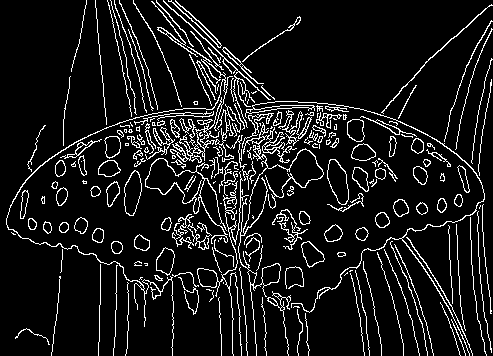

Corners:


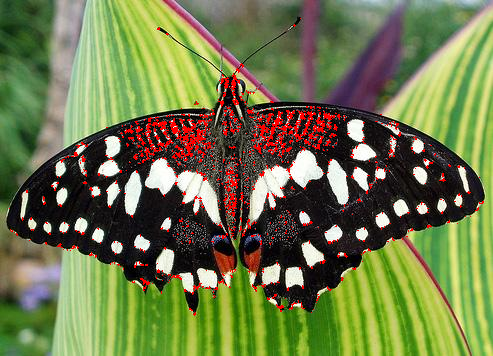

Blobs:


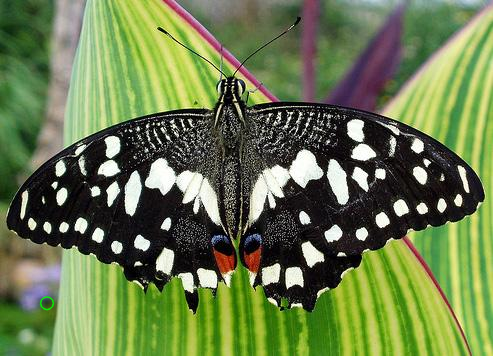

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Note: 'sample.jpg' must exist in your Colab file browser
img = cv2.imread('sample.jpg')
if img is None:
    print("Error: Could not load 'sample.jpg'. Please upload the file.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    # Corner Detection
    corners = cv2.cornerHarris(np.float32(gray), 2, 3, 0.04)
    img_corners = img.copy()
    img_corners[corners > 0.01 * corners.max()] = [0, 0, 255]

    # Blob Detection
    detector = cv2.SimpleBlobDetector_create()
    keypoints = detector.detect(gray)
    img_blobs = cv2.drawKeypoints(img, keypoints, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # Displaying results in Colab
    print("Edges:")
    cv2_imshow(edges)
    print("Corners:")
    cv2_imshow(img_corners)
    print("Blobs:")
    cv2_imshow(img_blobs)